## Import libraries

In [1]:
# Basic Libraries
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple

# Sklearn: Model Selection & Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline

# Sklearn: Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
                             r2_score, confusion_matrix)

# Sklearn: Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Sklearn: Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Imbalanced-learn: Oversampling
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# Load cleaned dataset

In [2]:
#load the final cleaned dataset
df=pd.read_csv('cleaned_data.csv')

# Overview of the dataset before cleanning

In [3]:
#load dataset before cleaning
before_cleanning_df=pd.read_csv('JobSalary2025.csv')
before_cleanning_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


# Data cleanning 

In [ ]:
selected_jobtitle="Data Scientist|Data Engineer|Data Specialist|Data Analyst|Machine Learning|ML|AI|Artificial Intelligence"
df= before_cleanning_df[before_cleanning_df['job_title'].str.contains(selected_jobtitle, case=False, na=False)]
df = df.replace('Machine Learning', 'ML', regex=True)
df=df.replace('Artificial Intelligence', 'AI', regex=True)
# Standardize AI Product titles
df['job_title'] = df['job_title'].replace('AI Product Lead', 'AI Product')
df['job_title'] = df['job_title'].replace('AI Product Manager', 'AI Product')
df['job_title'] = df['job_title'].replace('AI Product Owner', 'AI Product')
df['job_title'] = df['job_title'].replace('AI Product Specialist', 'AI Product')
# Standardize AI Solutions titles
df['job_title'] = df['job_title'].replace('AI Solution Architect', 'AI Solutions')
df['job_title'] = df['job_title'].replace('AI Solution Director', 'AI Solutions')
df['job_title'] = df['job_title'].replace('AI Solutions Lead', 'AI Solutions')
df['job_title'] = df['job_title'].replace('AI Solutions Specialist', 'AI Solutions')
df['job_title'] = df['job_title'].replace('AI Solutions Consultant', 'AI Solutions')
# Standardize AI Engineering titles
df['job_title'] = df['job_title'].replace('AI Software Engineer', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI Programmer', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI Software Development Engineer', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI Machine Learning Engineer', 'AI Engineer')
df['job_title'] = df['job_title'].replace('Lead AI Engineer', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI Engineering Lead', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI Engineering Manager', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI Data Engineer', 'AI Engineer')
df['job_title'] = df['job_title'].replace('AI ML Engineer', 'AI Engineer')
# Standardize AI Research titles
df['job_title'] = df['job_title'].replace('AI Researcher', 'AI Research')
df['job_title'] = df['job_title'].replace('AI Research Engineer', 'AI Research')
df['job_title'] = df['job_title'].replace('AI Research Scientist', 'AI Research')
# Standardize AI Architecture titles
df['job_title'] = df['job_title'].replace('GenAI Architect', 'AI Architect')
# Standardize AI Leadership titles
df['job_title'] = df['job_title'].replace('Head of AI', 'AI Leadership')
df['job_title'] = df['job_title'].replace('AI Lead', 'AI Leadership')
df['job_title'] = df['job_title'].replace('AI Tech Lead', 'AI Leadership')
df['job_title'] = df['job_title'].replace('Head of Applied AI', 'AI Leadership')
df['job_title'] = df['job_title'].replace('Applied AI ML Lead', 'AI Leadership')
df['job_title'] = df['job_title'].replace('Director of AI', 'AI Leadership')
# Standardize AI Governance / Strategy titles
df['job_title'] = df['job_title'].replace('AI Governance Specialist', 'AI Governance')
df['job_title'] = df['job_title'].replace('AI Governance Lead', 'AI Governance')
df['job_title'] = df['job_title'].replace('AI Data Scientist', 'AI Scientist')
# Drop less frequency(20) titles
drop=['Trainee', 'Clinical Aide','AIRS Solutions Specialist','AI Governance','Conversational AI Designer',
         'AI Strategist','AI Content Writer' ]
df = df[~df['job_title'].isin(drop)]
# Standardize ML Engineering titles
df['job_title'] = df['job_title'].replace('MLOps Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Developer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Software Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Infrastructure Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Model Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Platform Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Quality Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Modeler', 'ML Engineer')
df['job_title'] = df['job_title'].replace('Applied ML Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('Lead ML Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('Principal ML Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('Staff ML Engineer', 'ML Engineer')
df['job_title'] = df['job_title'].replace('ML Performance Engineer', 'ML Engineer')
# Standardize ML Research titles
df['job_title'] = df['job_title'].replace('ML Research Engineer', 'ML Researcher')
df['job_title'] = df['job_title'].replace('Applied ML Scientist', 'ML Scientist')
# Standardize ML Leadership titles
df['job_title'] = df['job_title'].replace('Director of ML', 'ML Leadership')
df['job_title'] = df['job_title'].replace('Head of ML', 'ML Leadership')
df['job_title'] = df['job_title'].replace('ML Manager', 'ML Leadership')
df['job_title'] = df['job_title'].replace('ML Lead', 'ML Leadership')
df['job_title'] = df['job_title'].replace('ML Tech Lead', 'ML Leadership')
df['job_title'] = df['job_title'].replace('Applied AI ML Lead', 'ML Leadership')
# Data Science titles
df['job_title'] = df['job_title'].replace('Applied Data Scientist', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Lead Data Scientist', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Principal Data Scientist', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Data Scientist Lead', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Data Scientist Manager', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Data Scientist Expert', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Data Scientist Associate', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Marketing Data Scientist', 'Data Scientist')
df['job_title'] = df['job_title'].replace('Staff Data Scientist', 'Data Scientist')
# Data Engineering titles
df['job_title'] = df['job_title'].replace('Big Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Cloud Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Azure Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Lead Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Principal Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Software Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Consultant Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Data Engineer 4', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Platform Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('Marketing Data Engineer', 'Data Engineer')
df['job_title'] = df['job_title'].replace('BI Data Engineer', 'Data Engineer')
# Data Analysis / BI titles
df['job_title'] = df['job_title'].replace('Business Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('BI Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Admin & Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Product Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Lead Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Financial Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Finance Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Staff Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Business Intelligence Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Principal Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Marketing Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Compliance Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Data Analyst Lead', 'Data Analyst')
df['job_title'] = df['job_title'].replace('BI & Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Fraud Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Advanced Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Big Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('CRM Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('People Data Analyst', 'Data Analyst')
df['job_title'] = df['job_title'].replace('Sales Data Analyst', 'Data Analyst')
# Data Specialist titles
df['job_title'] = df['job_title'].replace('Master Data Specialist', 'Data Specialist')

df.to_csv('cleaned_data.csv',index=False)

### Add new fetures for classification

In [ ]:

df=pd.read_csv('cleaned_data.csv')

df_c=df.copy()

min_salary = df_c['salary_in_usd'].min()
q25 = df_c['salary_in_usd'].quantile(0.25)
q50 = df_c['salary_in_usd'].quantile(0.50)
q75 = df_c['salary_in_usd'].quantile(0.75)
max_salary = df_c['salary_in_usd'].max()


bins = [min_salary, q25, q50, q75, max_salary]
range_labels = [
    f"{int(min_salary)}-{int(q25)}",
    f"{int(q25)}-{int(q50)}",
    f"{int(q50)}-{int(q75)}",
    f"{int(q75)}-{int(max_salary)}"
]

df_c['salary_category_range'] = pd.cut(
    df_c['salary_in_usd'],
    bins=bins,
    labels=range_labels,
    include_lowest=True
)

level_labels = ['Low', 'Medium', 'High', 'Very High']
df_c['salary_level'] = pd.cut(
    df_c['salary_in_usd'],
    bins=bins,
    labels=level_labels,
    include_lowest=True
)

df_c.to_csv('cleaned_data.csv',index=False)

# Overview after cleanning 

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63988 entries, 0 to 63987
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   work_year              63988 non-null  int64 
 1   experience_level       63988 non-null  object
 2   employment_type        63988 non-null  object
 3   job_title              63988 non-null  object
 4   salary                 63988 non-null  int64 
 5   salary_currency        63988 non-null  object
 6   salary_in_usd          63988 non-null  int64 
 7   employee_residence     63988 non-null  object
 8   remote_ratio           63988 non-null  int64 
 9   company_location       63988 non-null  object
 10  company_size           63988 non-null  object
 11  salary_category_range  63988 non-null  object
 12  salary_level           63988 non-null  object
dtypes: int64(4), object(9)
memory usage: 6.3+ MB


This dataset contains  job records with 11 features related to employee salaries and mixed of numerical and catagorical atttributes.  This dataset can be used to analyze the AI ML Data Science job salary trends across different cites. It provides a clear overview of the current data related jobs.

In [12]:
df.nunique()

work_year                   6
experience_level            4
employment_type             4
job_title                  19
salary                   7466
salary_currency            26
salary_in_usd            8290
employee_residence         93
remote_ratio                3
company_location           86
company_size                3
salary_category_range       4
salary_level                4
dtype: int64

From this output it visiable that this dataset contain 422 unique job title across 97 different locations. The salary currency has total 26 unique values, it indicates that the data collected from 26 different countries.

In [13]:
# show total job titles with their frequency
job_counts = df['job_title'].value_counts()

for job, count in job_counts.items():
    print(f"{job}  {count}")

Data Scientist  18796
Data Engineer  16391
Data Analyst  13864
ML Engineer  9284
AI Engineer  2094
Data Specialist  986
ML Researcher  704
ML Scientist  599
AI Architect  301
AI Developer  222
AI Scientist  150
AI Research  122
AI Leadership  116
AI Specialist  108
ML Leadership  85
AI Product  71
AI Solutions  39
ML Architect  32
ML Specialist  24


In [14]:
df.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,salary_category_range,salary_level
0,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,140000-185500,High
1,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,15000-100000,Low
2,2025,SE,FT,AI Product,175000,USD,175000,US,100,US,M,140000-185500,High
3,2025,SE,FT,AI Product,152900,USD,152900,US,100,US,M,140000-185500,High
4,2025,SE,FT,AI Engineer,97900,USD,97900,US,100,US,M,15000-100000,Low


In [15]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,63988.000000,6.398800e+04,63988.000000,63988.000000
mean,2024.267363,1.566170e+05,149006.990764,24.406139
std,0.768314,2.635331e+05,70402.589383,42.833943
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.000000e+05,100000.000000,0.000000
50%,2024.000000,1.400000e+05,140000.000000,0.000000
75%,2025.000000,1.867540e+05,185500.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


From this output, we can see that there are no part-time or hybrid roles(mixed remote and on-site). Either they do remote job or on office job. On average, the salary is closer to the minimum salary as compare to the maximum salary. Which highlights the *presence of extreme outliers*. 

# Visualization 

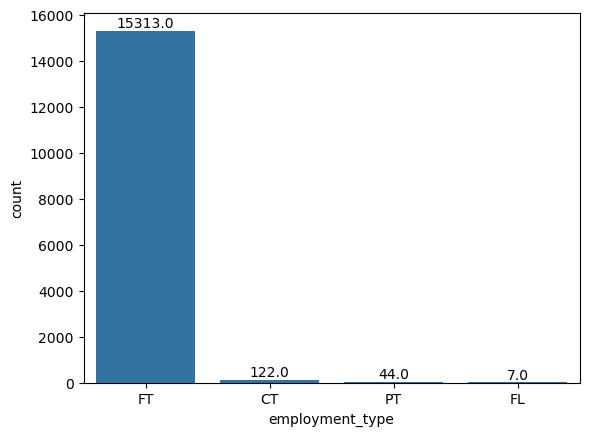

In [16]:
employees = df[df['remote_ratio'] == 100]

ax=sns.countplot(x='employment_type',data=employees)

for p in ax.patches:
    value = p.get_height()
    ax.annotate(str(value),
                (p.get_x() + p.get_width()/2, value),
                ha='center', va='bottom')             
plt.show()


This suggests that remote work is more common among full-time roles, rather than temporary or part-time employment types. Companies may prefer to offer remote work primarily to full-time stable positions.

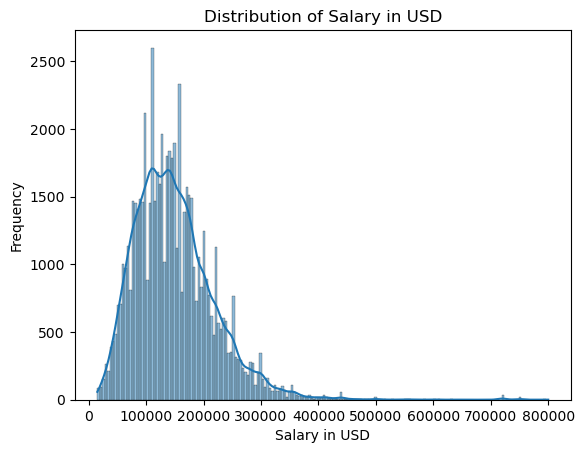

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['salary_in_usd'], kde=True)
plt.title("Distribution of Salary in USD")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.show()


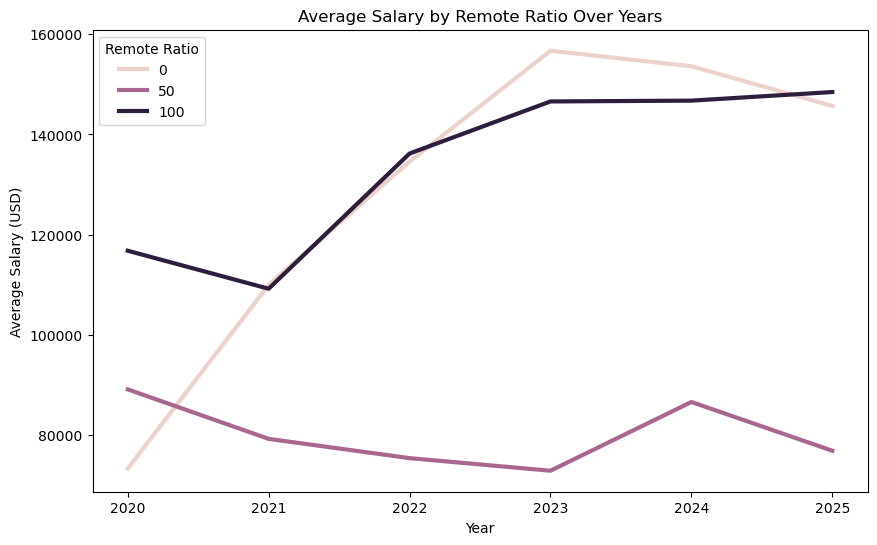

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df,
    x='work_year',
    y='salary_in_usd',
    hue='remote_ratio',
    estimator='mean',
    errorbar=None,   # removes shaded CI
    marker=None,     # no markers
    linewidth=3      # makes lines thicker/bolder
)

plt.title('Average Salary by Remote Ratio Over Years')
plt.xlabel('Year')
plt.ylabel('Average Salary (USD)')
plt.legend(title='Remote Ratio')
plt.show()


 ### Top 10 job title
 

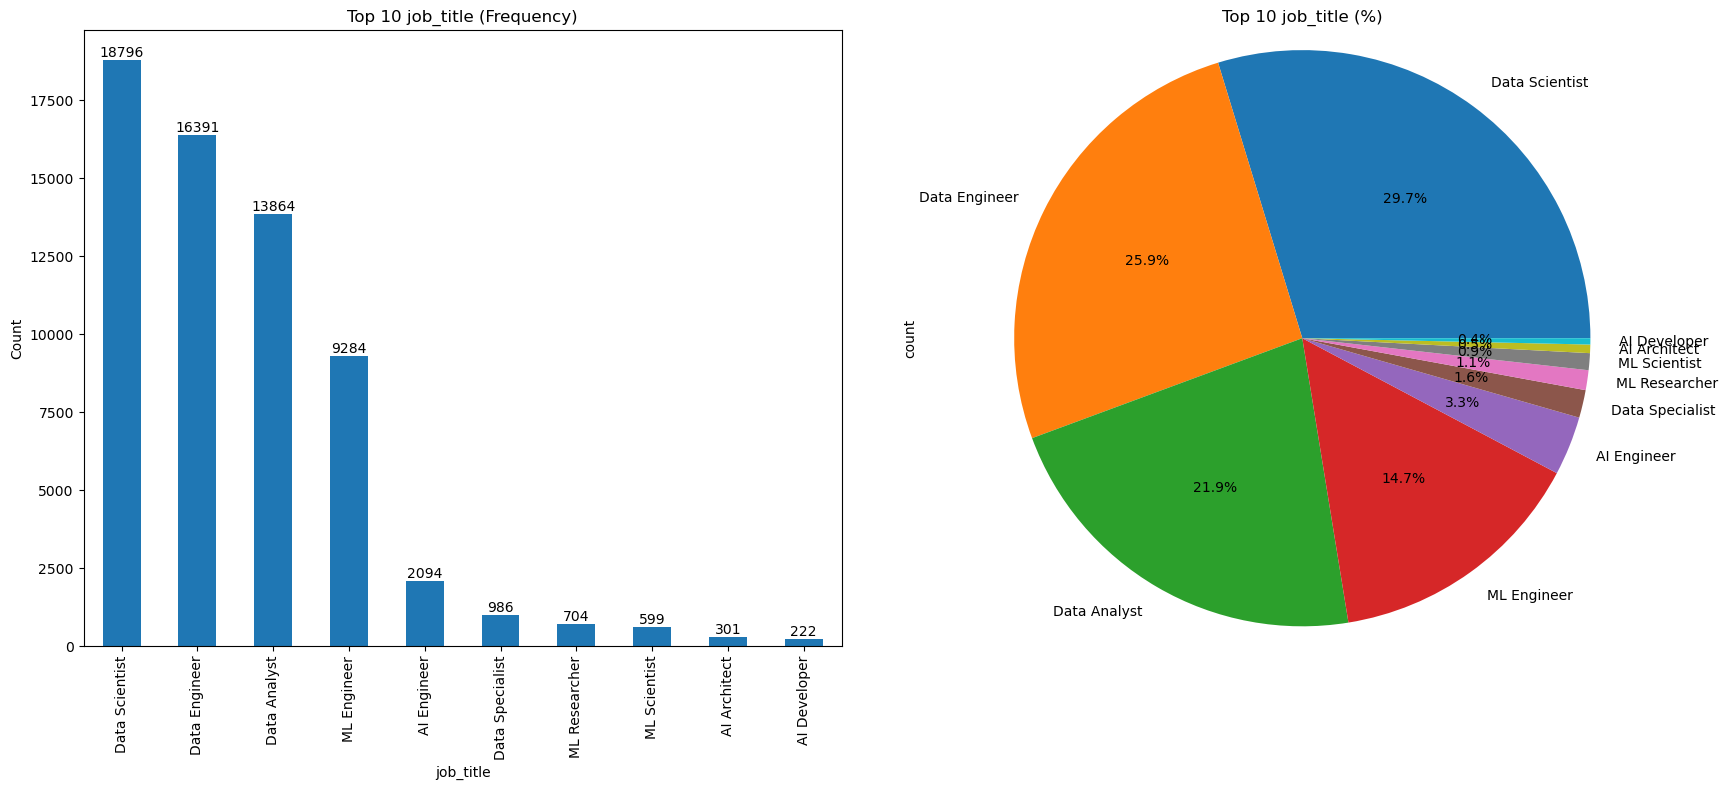

In [19]:
# Custom colors for PIE chart only
pie_colors = plt.cm.tab10.colors[:10]   # or any color list you want

top_10 = df['job_title'].value_counts().head(10)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# -----------------------------
# BAR CHART (remains blue)
# -----------------------------
top_10.plot(kind="bar", ax=axes[0])   # no color added
axes[0].set_title("Top 10 job_title (Frequency)")
axes[0].set_ylabel("Count")
axes[0].set_xlabel("job_title")

# Add labels on bars
for p in axes[0].patches:
    axes[0].annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center', va='bottom'
    )

# -----------------------------
# PIE CHART (custom colors here)
# -----------------------------
top_10.plot(
    kind="pie",
    autopct="%1.1f%%",
    ax=axes[1],
    colors=pie_colors   # pie colors changed
)

axes[1].set_title("Top 10 job_title (%)")
axes[1].axis("equal")

plt.tight_layout()
plt.show()


### Salary visualization

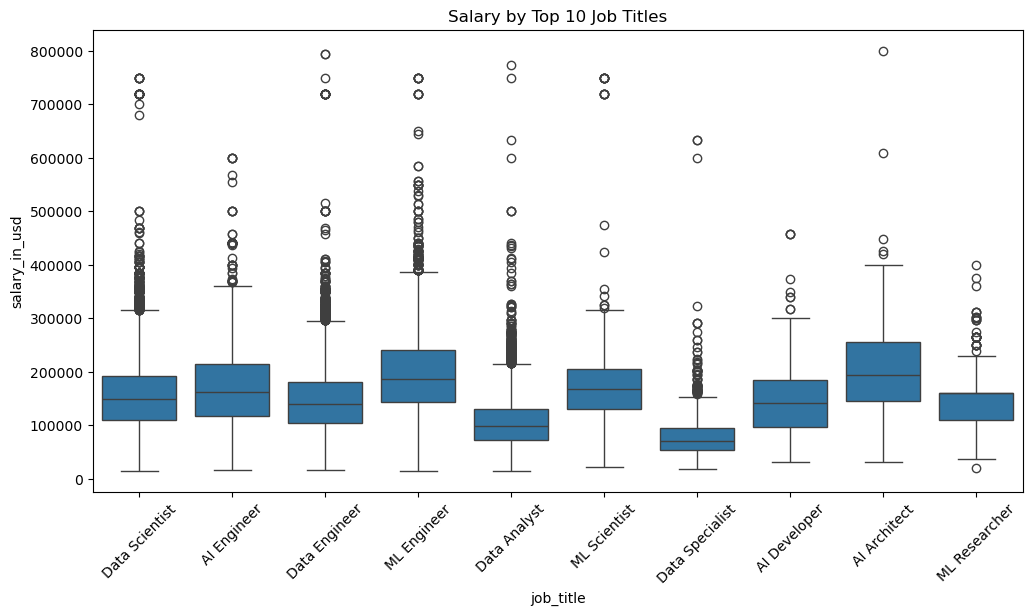

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get top 10 most common job titles
top_jobs = df['job_title'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.boxplot(x='job_title', y='salary_in_usd', data=df[df['job_title'].isin(top_jobs)])
plt.xticks(rotation=45)
plt.title('Salary by Top 10 Job Titles')
plt.show()


experience_level
SE    37511
MI    17679
EN     7520
EX     1278
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

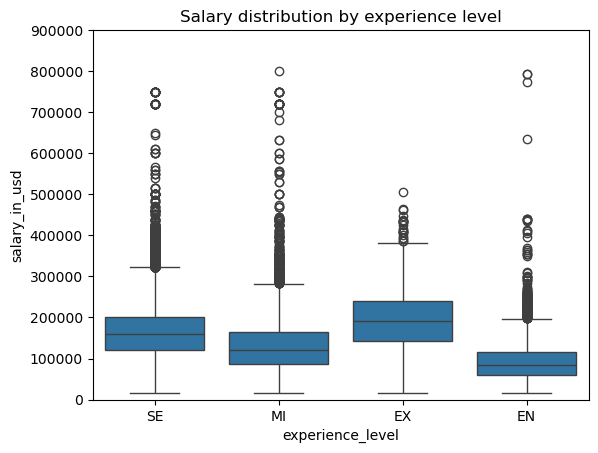

In [21]:
print(df['experience_level'].value_counts())
sns.boxplot(x='experience_level', y='salary_in_usd', data=df)

plt.ylim(0,900000)
plt.title('Salary distribution by experience level')
plt.show

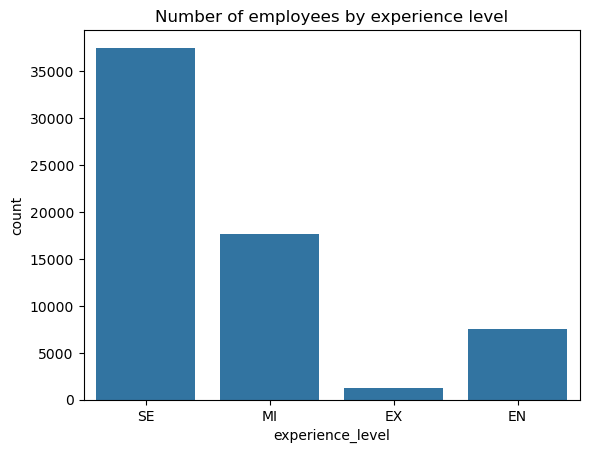

In [22]:

sns.countplot(x='experience_level',data=df)
plt.title('Number of employees by experience level')

plt.show()

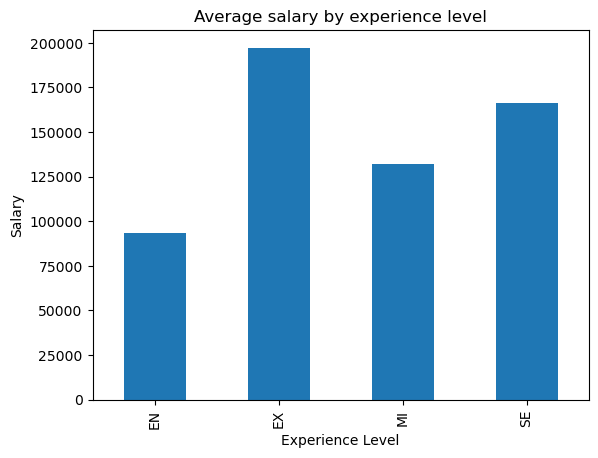

In [23]:
average_salary=df.groupby('experience_level')['salary_in_usd'].mean()

average_salary.plot(kind="bar")
plt.title("Average salary by experience level")
plt.ylabel("Salary")
plt.xlabel('Experience Level')

plt.show()

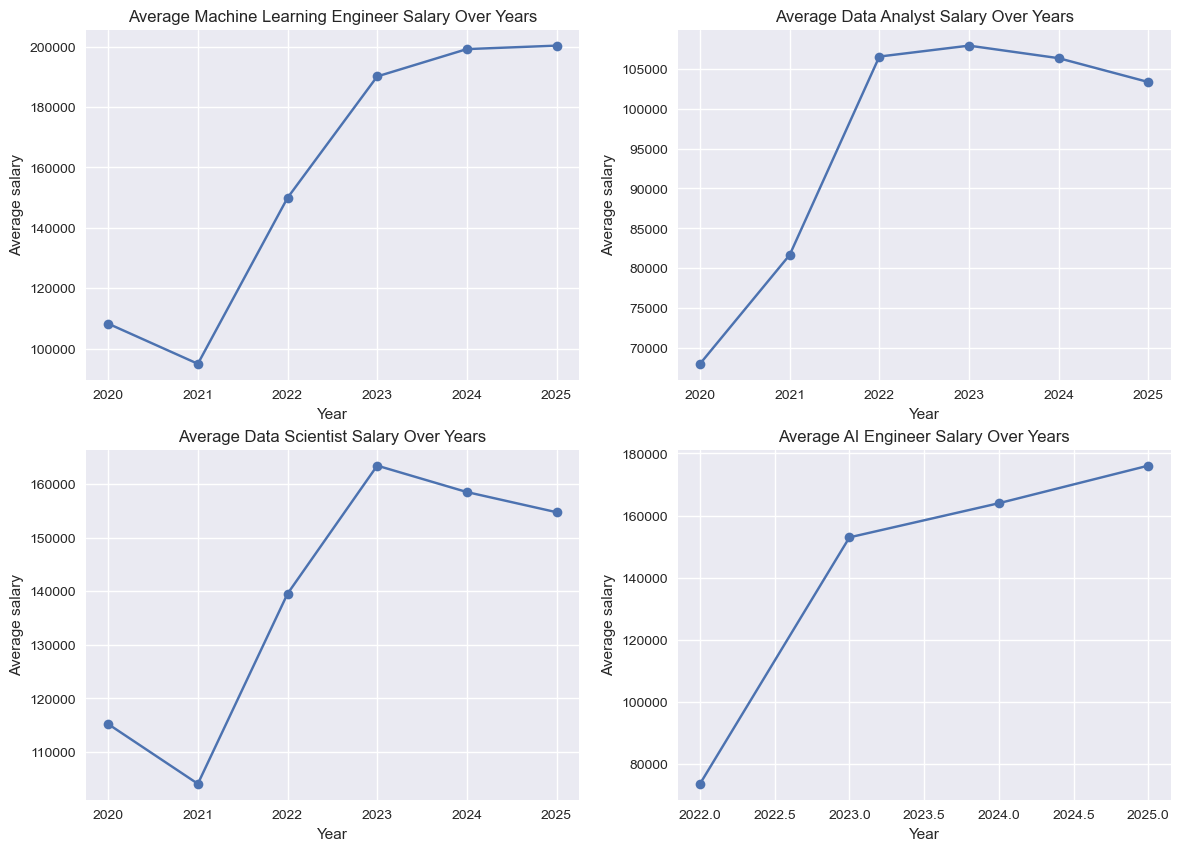

In [24]:
plt.style.use("seaborn-v0_8")
fig = plt.figure(figsize=(14,10))  # 👈 Bigger frame

colors = ["#FF5733", "#3498DB", "#2ECC71", "#9B59B6"] 

ax1=fig.add_subplot(2,2,1)
ax2=fig.add_subplot(2,2,2)
ax3=fig.add_subplot(2,2,3)
ax4=fig.add_subplot(2,2,4)

ai=df[df["job_title"].str.contains("ML Engineer",case=False, na=False)]
yearly_avg_salary=ai.groupby("work_year")["salary_in_usd"].mean().reset_index()
ax1.plot(yearly_avg_salary["work_year"],yearly_avg_salary["salary_in_usd"], marker='o')

ax1.set_title("Average Machine Learning Engineer Salary Over Years")
ax1.set_xlabel("Year")
ax1.set_ylabel("Average salary")
ax1.grid(True)

ai=df[df["job_title"].str.contains("Data Analyst",case=False, na=False)]
yearly_avg_salary=ai.groupby("work_year")["salary_in_usd"].mean().reset_index()
ax2.plot(yearly_avg_salary["work_year"],yearly_avg_salary["salary_in_usd"], marker='o')
ax2.set_title("Average Data Analyst Salary Over Years")
ax2.set_xlabel("Year")
ax2.set_ylabel("Average salary")
ax2.grid(True)

ai=df[df["job_title"].str.contains("Data Scientist",case=False, na=False)]
yearly_avg_salary=ai.groupby("work_year")["salary_in_usd"].mean().reset_index()
ax3.plot(yearly_avg_salary["work_year"],yearly_avg_salary["salary_in_usd"], marker='o')
ax3.set_title("Average Data Scientist Salary Over Years")
ax3.set_xlabel("Year")
ax3.set_ylabel("Average salary")
ax3.grid(True)

ai=df[df["job_title"].str.contains("AI Engineer",case=False, na=False)]
yearly_avg_salary=ai.groupby("work_year")["salary_in_usd"].mean().reset_index()
ax4.plot(yearly_avg_salary["work_year"],yearly_avg_salary["salary_in_usd"], marker='o')
ax4.set_title("Average AI Engineer Salary Over Years")
ax4.set_xlabel("Year")
ax4.set_ylabel("Average salary")
ax4.grid(True)

plt.show()

These line plots in figure-06 show the average salary trends for four job roles. The ML Engineer salary shows a downward line on 2021 after that it shows the most significant growth. The Data Analyst salary saw increasing trend from 2020 to 2022 and then experienced a slight decline in 2024 and 2025. The data scientist salary shows a similar pattern like data analyst salary. But the AI Engineer salary follows the same growth trend as Machine Learning salary.

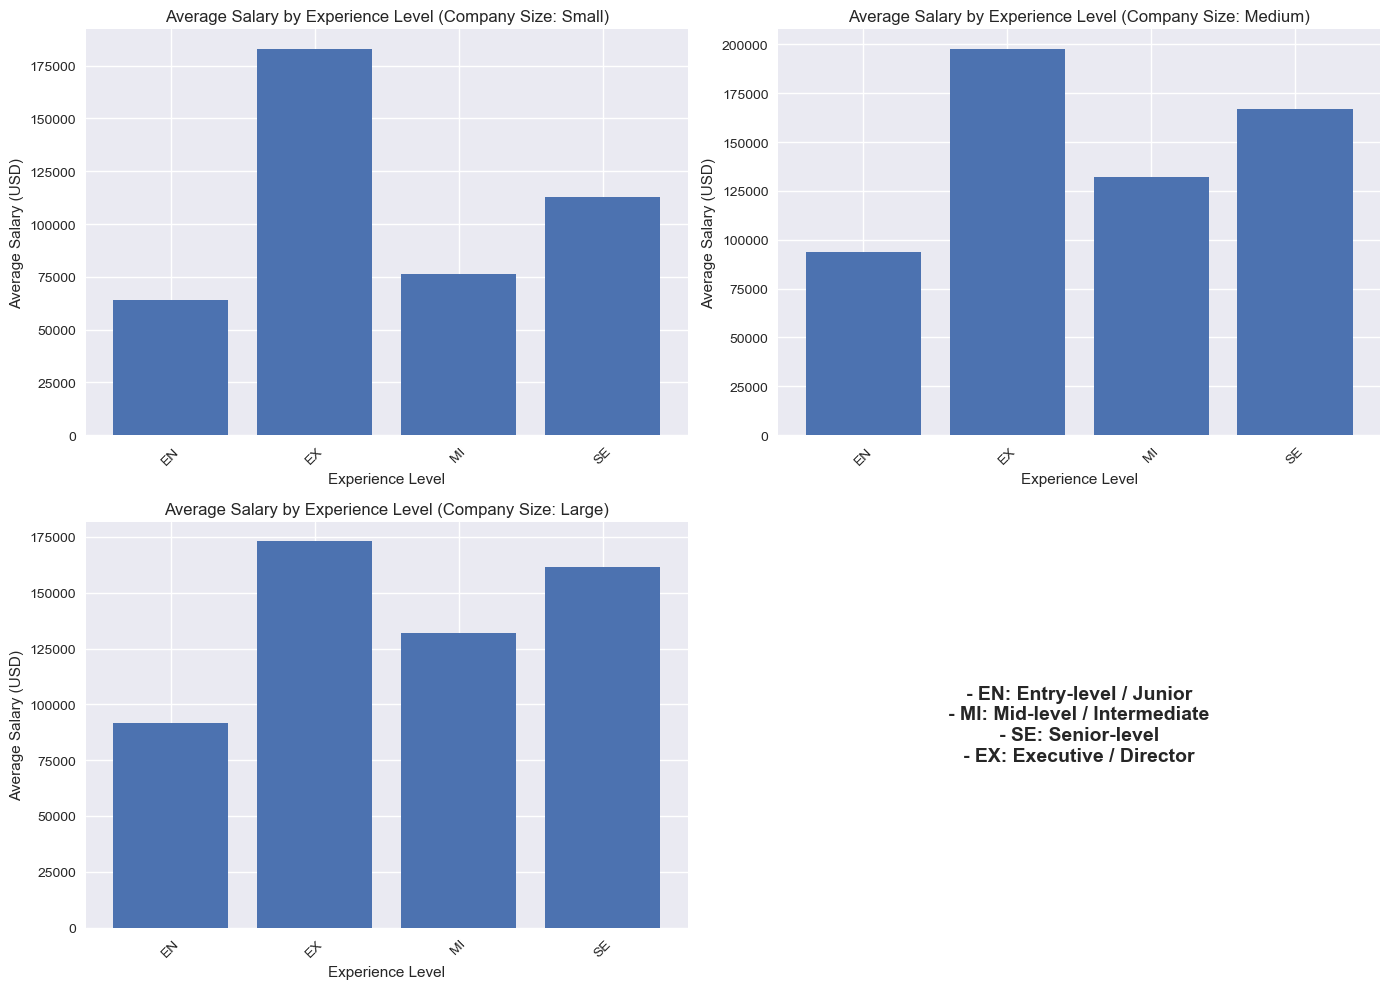

In [25]:

plt.style.use("seaborn-v0_8")
fig = plt.figure(figsize=(14,10))  # 👈 Bigger frame

colors = ["#FF5733", "#3498DB", "#2ECC71", "#9B59B6"] 

ax1=fig.add_subplot(2,2,1)
ax2=fig.add_subplot(2,2,2)
ax3=fig.add_subplot(2,2,3)
ax4 = fig.add_subplot(2,2,4)

small= df[df["company_size"].str.contains("S", case=False, na=False)]
yearly_avg_salary = small.groupby("experience_level")["salary_in_usd"].mean().reset_index()
ax1.bar(yearly_avg_salary["experience_level"], yearly_avg_salary["salary_in_usd"])
ax1.set_title("Average Salary by Experience Level (Company Size: Small)")
ax1.set_xlabel("Experience Level")
ax1.set_ylabel("Average Salary (USD)")
ax1.grid(True)
ax1.tick_params(axis='x', rotation=45)


medium= df[df["company_size"].str.contains("M", case=False, na=False)]
yearly_avg_salary = medium.groupby("experience_level")["salary_in_usd"].mean().reset_index()
ax2.bar(yearly_avg_salary["experience_level"], yearly_avg_salary["salary_in_usd"])
ax2.set_title("Average Salary by Experience Level (Company Size: Medium)")
ax2.set_xlabel("Experience Level")
ax2.set_ylabel("Average Salary (USD)")
ax2.grid(True)
ax2.tick_params(axis='x', rotation=45)


large= df[df["company_size"].str.contains("L", case=False, na=False)]
yearly_avg_salary = large.groupby("experience_level")["salary_in_usd"].mean().reset_index()
ax3.bar(yearly_avg_salary["experience_level"], yearly_avg_salary["salary_in_usd"])
ax3.set_title("Average Salary by Experience Level (Company Size: Large)")
ax3.set_xlabel("Experience Level")
ax3.set_ylabel("Average Salary (USD)")
ax3.grid(True)
ax3.tick_params(axis='x', rotation=45)

ax4.axis('off')
text = (
    "- EN: Entry-level / Junior\n"
    "- MI: Mid-level / Intermediate\n"
    "- SE: Senior-level\n"
    "- EX: Executive / Director"
)

ax4.text(0.5, 0.5, text, fontsize=14, ha='center', va='center', fontweight='bold')



plt.tight_layout()
plt.show()

This graph analyzes the relationship between average annual salary, professional experience level, and organizational scale (company size). The results demonstrate that Experience Level is the primary determinant of salary across all company sizes, with Executive/Director roles consistently yielding the highest compensation. However, a significant moderating effect is exerted by Company Size, particularly for intermediate and senior roles, where larger organizations offer substantially higher compensation than small enterprises. 